In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [51]:
data = {
    "Height": [145,147,149,150,152,154,155,157,158,160,
               161,163,164,166,167,169,170,172,173,175,
               176,178,179,181,182,184,185,187,188,190,
               191,193,194,196,197,199,200,202,203,205],

    "Weight": [44,39,47,43,51,46,55,49,57,52,
               60,54,63,58,66,61,68,64,72,67,
               75,70,78,73,81,76,84,79,88,82,
               91,85,94,89,97,90,99,93,102,96]
}

df=pd.DataFrame(data)

<Axes: >

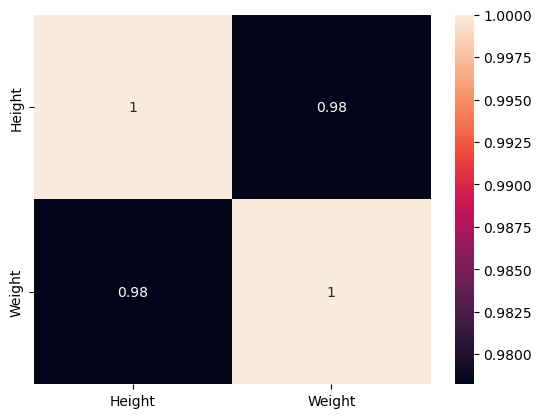

In [52]:
corr=df.corr()
sns.heatmap(corr,annot=True)

<Axes: xlabel='Height', ylabel='Weight'>

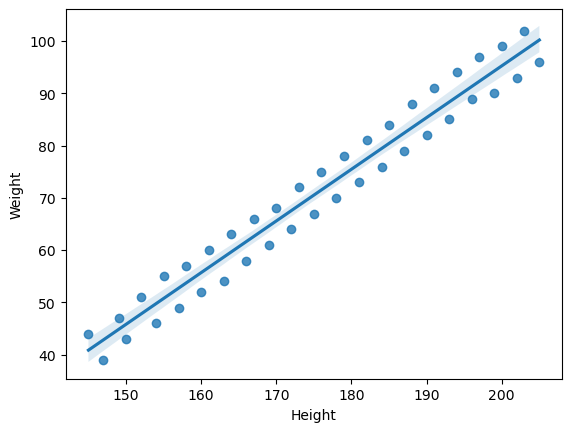

In [53]:
sns.regplot(data=df,x="Height",y="Weight",)

In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X=df[["Height"]]
y=df[["Weight"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

pipeline=Pipeline([
    ("scaler",StandardScaler()),
    ("model",LinearRegression())
])

pipeline.fit(X_train,y_train)

y_pred=pipeline.predict(X_test)

print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))


0.9106982849381086
18.72420041930352
4.164512796345976


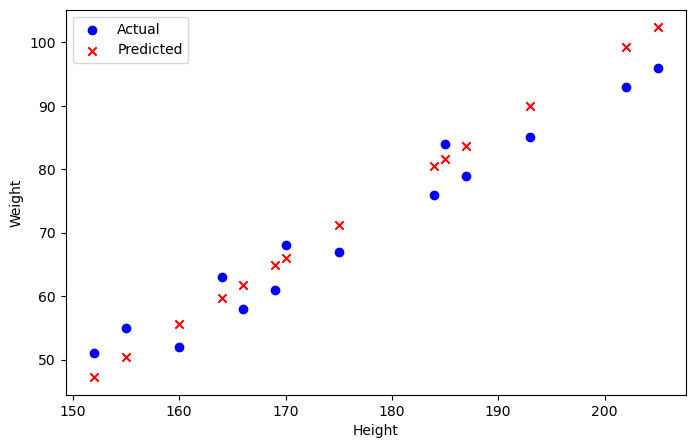

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Actual values
plt.scatter(X_test, y_test, color="blue", label="Actual")

# Predicted values
plt.scatter(X_test, y_pred, color="red", marker="x", label="Predicted")

plt.xlabel("Height")
plt.ylabel("Weight")
plt.legend()
plt.show()